# Занятие 01. Первичный анализ внешнего набора данных: Processed Data for EV Powertrain Efficiency, Mendeley Data

## Теоретический блок

Набор данных рассматривается как инженерная таблица наблюдений. Наблюдение -
одна строка, соответствующая измеренному или расчетному состоянию объекта.
Признак (feature) - входная величина анализа. Диагностический столбец -
величина, полезная для объяснения источника данных, но потенциально опасная
как вход модели из-за утечки данных (data leakage).

Источник: https://data.mendeley.com/datasets/kbwr2z8r3y.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/mendeley_ev_powertrain_efficiency_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
DATASET_ID = "mendeley_ev_powertrain_efficiency"
DATASET_TITLE = "Processed Data for EV Powertrain Efficiency, Mendeley Data"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    return data.index[~test_mask], data.index[test_mask], test_groups


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/mendeley_ev_powertrain_efficiency_features.csv
Размер feature-таблицы: (10826, 11)


,sample_id,profile_id,time_index,vehicle_speed_m_s,acceleration_m_s2,slope_rad,motor_speed_rpm,motor_torque_nm,motor_efficiency,drivetrain_efficiency,is_allowed
0,1,3,1651657771,3.147222,-0.244444,0.000000,1324.864779,-26.660376,1.000000,0.931200,1
1,2,3,1651657808,3.666667,2.327778,-0.057269,1543.531781,70.857383,0.918891,0.855672,0
2,3,3,1651657814,6.830556,0.433333,-0.110345,2875.412613,77.119948,0.937602,0.873095,0
3,4,3,1651657826,3.508333,0.038889,0.000000,1476.879272,-9.614097,1.000000,0.931200,1
4,5,3,1651657828,3.586111,-0.313889,0.000000,1509.620856,-30.896835,1.000000,0.931200,1


In [2]:
metadata_text = METADATA_FILE.read_text(encoding="utf-8") if METADATA_FILE.exists() else "Метаданные не найдены."
print(metadata_text)


# Processed Data for EV Powertrain Efficiency, Mendeley Data

- Идентификатор: `mendeley_ev_powertrain_efficiency`.
- Источник: https://data.mendeley.com/datasets/kbwr2z8r3y.
- Лицензия и доступ: CC BY 4.0.
- Статус подготовки: `prepared`.
- Число строк в компактной учебной выборке: 10826.

Методическое назначение: расширенные блокноты занятий 1-3 с реальными
или открытыми инженерными данными. Feature-CSV используется для базовой
модели, diagnostics-CSV - для пояснения происхождения целевых переменных,
ограничений и возможной утечки данных.

Дополнительные замечания:
- Целевая переменная регрессии: `drivetrain_efficiency`.
- Целевая переменная классификации: `is_allowed`, производная от нижнего квантиля КПД.
- Для проверки качества используется разбиение по датам поездок, а не случайное перемешивание соседних точек траектории.



In [3]:
dataset_passport = pd.DataFrame(
    {
        "field": [
            "dataset_id",
            "title",
            "source_status",
            "rows_features",
            "columns_features",
            "group_column",
            "time_column",
            "regression_target",
            "classification_target",
        ],
        "value": [
            DATASET_ID,
            DATASET_TITLE,
            source_status,
            features_df.shape[0],
            features_df.shape[1],
            GROUP_COLUMN,
            TIME_COLUMN,
            "drivetrain_efficiency",
            "is_allowed",
        ],
    }
)
dataset_passport


,field,value
0,dataset_id,mendeley_ev_powertrain_efficiency
1,title,"Processed Data for EV Powertrain Efficiency, M..."
2,source_status,external
3,rows_features,10826
4,columns_features,11
5,group_column,profile_id
6,time_column,time_index
7,regression_target,drivetrain_efficiency
8,classification_target,is_allowed


In [4]:
analysis_columns = ['vehicle_speed_m_s', 'acceleration_m_s2', 'slope_rad', 'motor_speed_rpm', 'motor_torque_nm', 'motor_efficiency', 'drivetrain_efficiency']
features_df[analysis_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
vehicle_speed_m_s,10826.0,10.059565,7.979175,0.000000,1.940278,9.416666,17.291667,30.438889
acceleration_m_s2,10826.0,0.004386,0.732023,-4.594444,-0.236111,0.000000,0.297222,5.011111
slope_rad,10826.0,0.000575,0.052881,-0.276108,-0.018491,0.000000,0.018710,0.298983
motor_speed_rpm,10826.0,4234.706777,3358.939354,0.000000,816.785567,3964.070256,7279.155558,12813.652467
motor_torque_nm,10826.0,-17.041883,48.630216,-328.071350,-41.792665,-6.576426,4.437457,174.132751
motor_efficiency,10826.0,0.918076,0.191167,0.000000,0.950622,1.000000,1.000000,1.000000
drivetrain_efficiency,10826.0,0.855257,0.177261,0.009312,0.931200,0.931200,0.931200,0.932100


In [5]:
missing_table = (
    features_df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_share=lambda x: x["missing_count"] / len(features_df))
)
missing_table[missing_table["missing_count"] > 0]


,missing_count,missing_share


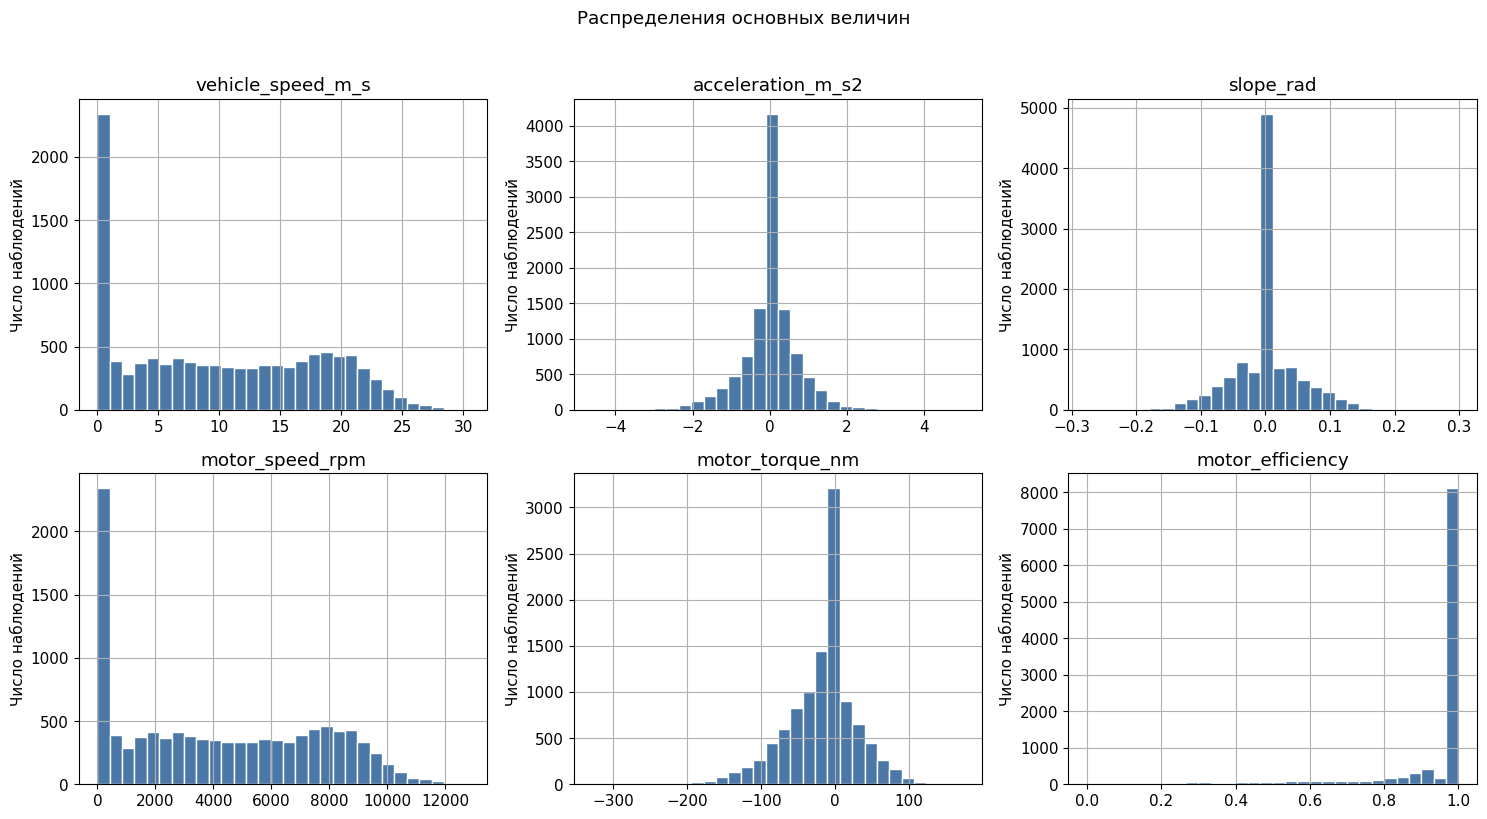

In [6]:
numeric_columns = features_df.select_dtypes(include=[np.number]).columns.tolist()
shown_columns = [column for column in analysis_columns if column in numeric_columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, column in zip(axes, shown_columns[:6]):
    ax.hist(features_df[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Число наблюдений")
for ax in axes[len(shown_columns[:6]):]:
    ax.set_axis_off()
plt.suptitle("Распределения основных величин", y=1.02)
plt.tight_layout()
plt.show()


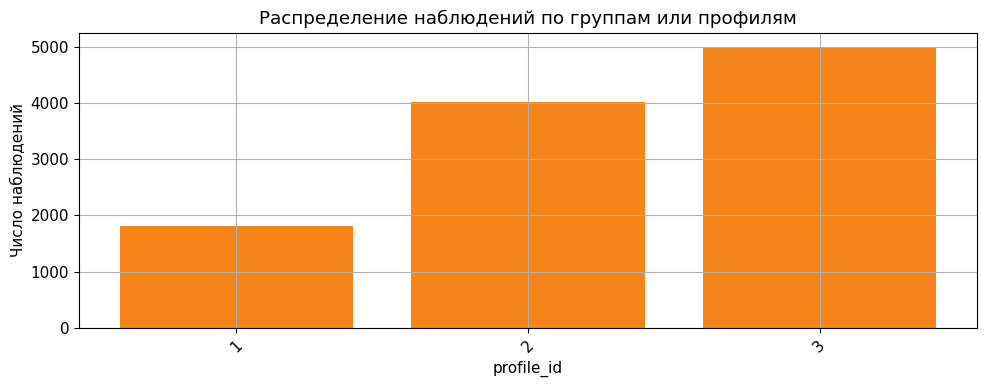

profile_id
1    1818
2    4008
3    5000
Name: count, dtype: int64

In [7]:
if GROUP_COLUMN in features_df.columns:
    group_counts = features_df[GROUP_COLUMN].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(group_counts.index.astype(str), group_counts.values, color="#f58518")
    ax.set_xlabel(GROUP_COLUMN)
    ax.set_ylabel("Число наблюдений")
    ax.set_title("Распределение наблюдений по группам или профилям")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
group_counts.head(20) if GROUP_COLUMN in features_df.columns else "Групповой столбец отсутствует"


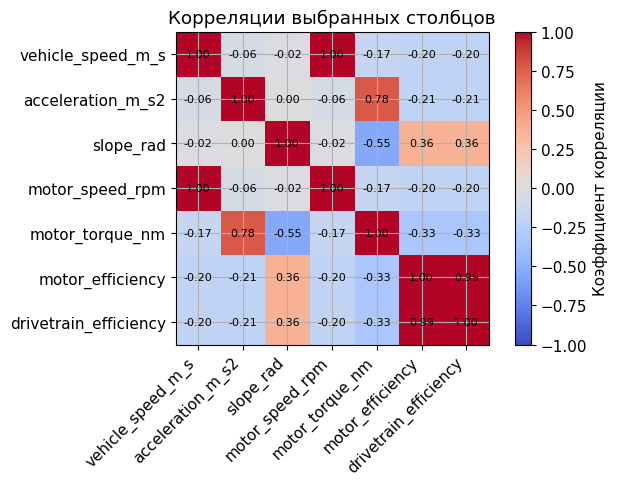

In [8]:
plot_correlation_heatmap(
    features_df,
    [column for column in analysis_columns if column in features_df.columns],
    "Корреляции выбранных столбцов",
)


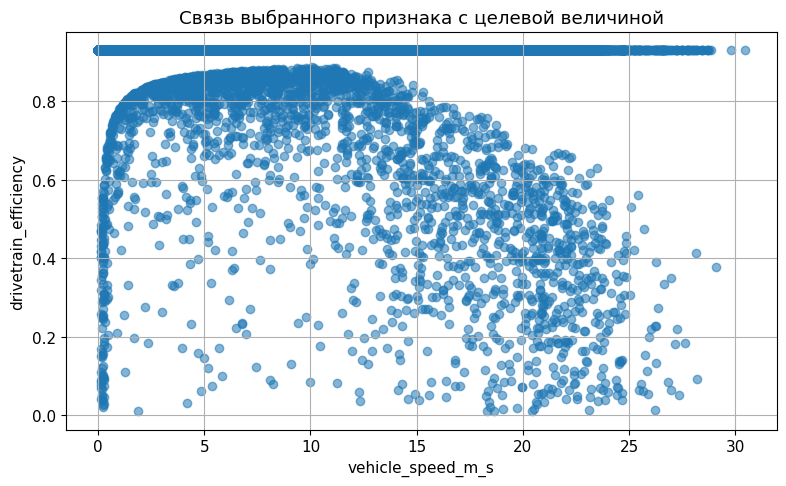

In [9]:
x_column = analysis_columns[0]
y_column = "drivetrain_efficiency"
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(features_df[x_column], features_df[y_column], alpha=0.55)
ax.set_xlabel(x_column)
ax.set_ylabel(y_column)
ax.set_title("Связь выбранного признака с целевой величиной")
plt.tight_layout()
plt.show()


## Задание

1. Опишите источник данных, объект наблюдения и единицу наблюдения.
2. Разделите столбцы на измеряемые, расчетные, служебные и диагностические.
3. Постройте не менее двух графиков и одну таблицу описательной статистики.
4. Объясните, какие столбцы могут привести к утечке данных в занятиях 02-03.
5. Сформулируйте индивидуальный инженерный вывод.
